# Model Comparison & Thesis Figures

Compares all trained models and generates publication-ready figures.

**Research Question**: Is it better to have separate models per parameter or a single multi-output model?

In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10

OUTPUT_DIR = Path('../../outputs')
FIGURES_DIR = Path('../../outputs/comparison/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def load_json(path):
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None

results = {
    'kmax_regression': load_json(OUTPUT_DIR / 'kmax/regression/results.json'),
    'kmax_binned': load_json(OUTPUT_DIR / 'kmax/binned_classification/results.json'),
    'dual_output': load_json(OUTPUT_DIR / 'comparison/dual_output/results.json'),
}

for name, data in results.items():
    status = '✓' if data else '✗ (run notebook first)'
    print(f'{name}: {status}')

kmax_regression: ✓
kmax_binned: ✓
dual_output: ✓


## Comparison Table

In [3]:
rows = []

# Baseline
rows.append({'Model': '61-class classification (baseline)', 'Type': 'Classification', 'Metric': 'Accuracy', 'Value': 0.05})

if results['kmax_regression']:
    r = results['kmax_regression']
    rows.append({'Model': 'Single-output kmax regression', 'Type': 'Regression', 'Metric': 'R²', 'Value': r['metrics']['r2']})
    rows.append({'Model': 'Single-output kmax regression', 'Type': 'Regression', 'Metric': 'MAE', 'Value': r['metrics']['mae']})

if results['kmax_binned']:
    r = results['kmax_binned']
    rows.append({'Model': '8-bin classification', 'Type': 'Classification', 'Metric': 'Accuracy', 'Value': r['8_bins']['accuracy']})
    rows.append({'Model': '12-bin classification', 'Type': 'Classification', 'Metric': 'Accuracy', 'Value': r['12_bins']['accuracy']})

if results['dual_output']:
    r = results['dual_output']
    rows.append({'Model': 'Dual-output (kmin)', 'Type': 'Regression', 'Metric': 'R²', 'Value': r['kmin']['r2']})
    rows.append({'Model': 'Dual-output (kmax)', 'Type': 'Regression', 'Metric': 'R²', 'Value': r['kmax']['r2']})

df = pd.DataFrame(rows)
print(df.to_string(index=False))

                             Model           Type   Metric    Value
61-class classification (baseline) Classification Accuracy 0.050000
     Single-output kmax regression     Regression       R² 0.702445
     Single-output kmax regression     Regression      MAE 6.781390
              8-bin classification Classification Accuracy 0.491875
             12-bin classification Classification Accuracy 0.378125
                Dual-output (kmin)     Regression       R² 0.897346
                Dual-output (kmax)     Regression       R² 0.608312


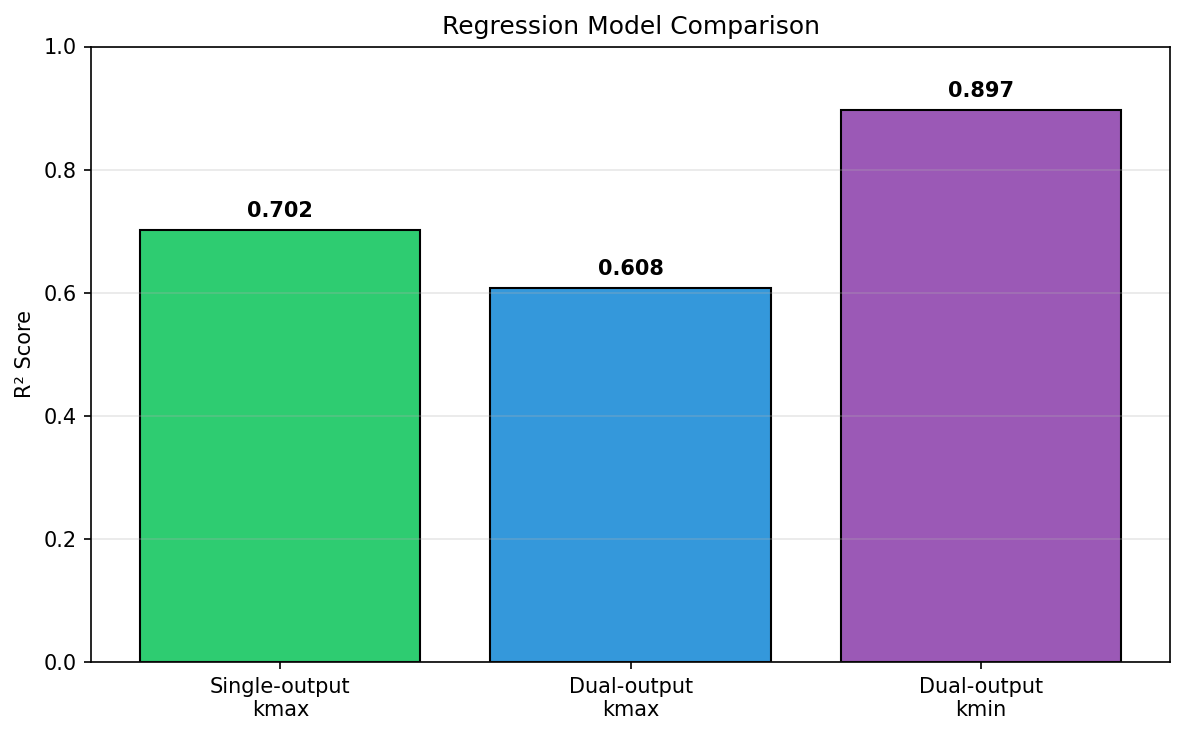

In [4]:
r2_data = []

if results['kmax_regression']:
    r2_data.append(('Single-output\nkmax', results['kmax_regression']['metrics']['r2']))

if results['dual_output']:
    r2_data.append(('Dual-output\nkmax', results['dual_output']['kmax']['r2']))
    r2_data.append(('Dual-output\nkmin', results['dual_output']['kmin']['r2']))

if r2_data:
    names, values = zip(*r2_data)
    colors = ['#2ecc71', '#3498db', '#9b59b6']
    
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(names, values, color=colors[:len(values)], edgecolor='black')
    ax.set_ylabel('R² Score')
    ax.set_title('Regression Model Comparison')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', 
                ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'r2_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No regression results yet. Run training notebooks first.')

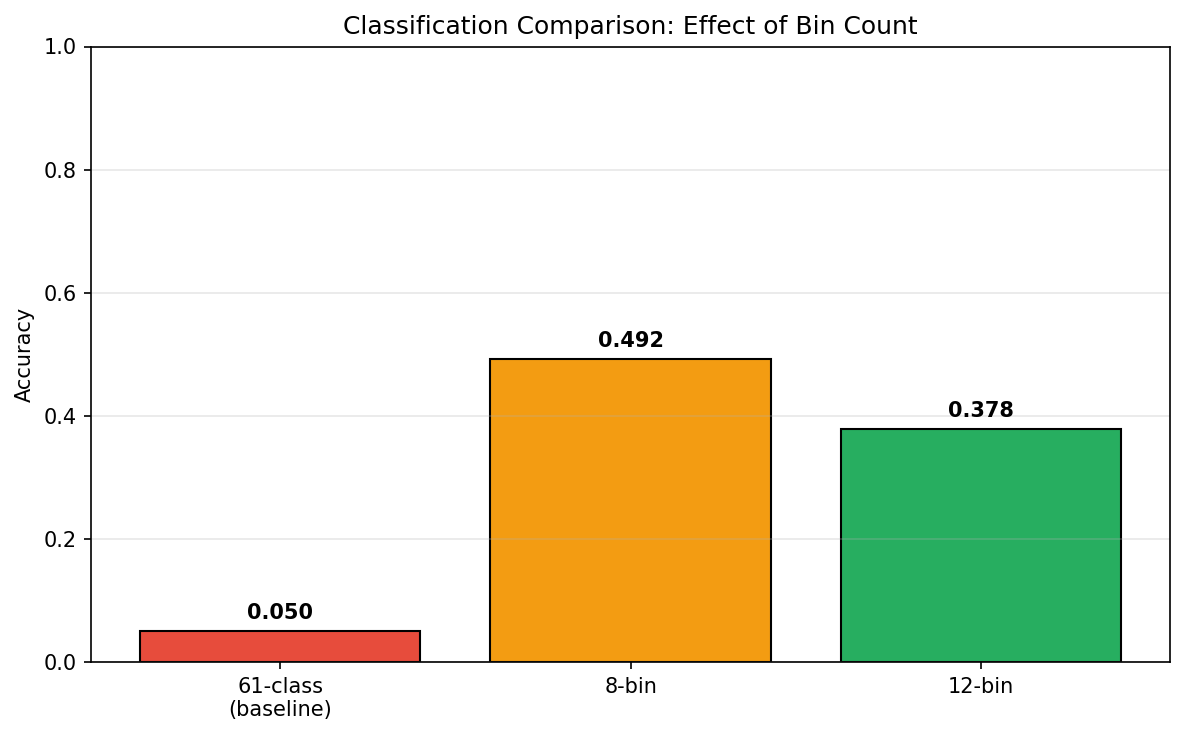

In [5]:
if results['kmax_binned']:
    acc_data = [
        ('61-class\n(baseline)', 0.05),
        ('8-bin', results['kmax_binned']['8_bins']['accuracy']),
        ('12-bin', results['kmax_binned']['12_bins']['accuracy']),
    ]
    
    names, values = zip(*acc_data)
    colors = ['#e74c3c', '#f39c12', '#27ae60']
    
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(names, values, color=colors, edgecolor='black')
    ax.set_ylabel('Accuracy')
    ax.set_title('Classification Comparison: Effect of Bin Count')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', 
                ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'classification_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

## Summary

In [6]:
print('='*60)
print('SUMMARY')
print('='*60)

print('\nResearch Question:')
print('Single model per parameter vs multi-output model?')

if results['kmax_regression'] and results['dual_output']:
    single_r2 = results['kmax_regression']['metrics']['r2']
    dual_r2 = results['dual_output']['kmax']['r2']
    
    print(f'\nkmax R² comparison:')
    print(f'  Single-output: {single_r2:.4f}')
    print(f'  Dual-output:   {dual_r2:.4f}')
    
    if single_r2 > dual_r2:
        print(f'\n→ Single-output performs better by {(single_r2-dual_r2):.4f}')
        print('→ Recommendation: Use separate models')
    else:
        print(f'\n→ Dual-output performs better by {(dual_r2-single_r2):.4f}')
        print('→ Recommendation: Use multi-output model')

print('\n' + '='*60)

SUMMARY

Research Question:
Single model per parameter vs multi-output model?

kmax R² comparison:
  Single-output: 0.7024
  Dual-output:   0.6083

→ Single-output performs better by 0.0941
→ Recommendation: Use separate models



In [7]:
summary = {'models': results, 'comparison': df.to_dict('records') if len(rows) > 1 else []}

with open(FIGURES_DIR / 'comparison_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print(f'Saved to {FIGURES_DIR}')

Saved to ../../outputs/comparison/figures
